# Stage 4: Inflation Forecasting & MPC Policy Classification (AI Layer)
This notebook implements the machine learning layers of the project:
1. **Core Inflation Forecasting (Prophet):** Predicts the Core CPI YoY series 6 months out to capture seasonal patterns and outline future trends with 90% confidence bands.
2. **MPC Policy Action Classifier (XGBoost):** Classifies monetary policy decisions into *Rate Hike* vs *Hold/Cut* using inflation lag features, validated using TimeSeriesSplit.
3. **Explainable AI (SHAP):** Explains model predictions using SHAP feature importances and single-decision force plots.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
import xgboost as xgb
import shap
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report, confusion_matrix
import os

# Load cleaned CPI data
df_cpi = pd.read_csv('../data/cleaned_cpi.csv')
df_cpi['date'] = pd.to_datetime(df_cpi['date'])

# Load processed MPC decisions dataset
df_mpc = pd.read_csv('../data/processed_cpi_mpc.csv')
df_mpc['date'] = pd.to_datetime(df_mpc['date'])

os.makedirs('../outputs', exist_ok=True)

## 1. Core CPI Inflation Forecasting (Prophet)
Prophet is ideal for Indian macroeconomic indicators because it handles seasonal monsoon effects and crop harvest cycles automatically. We use an additive seasonality model with a 90% confidence interval.

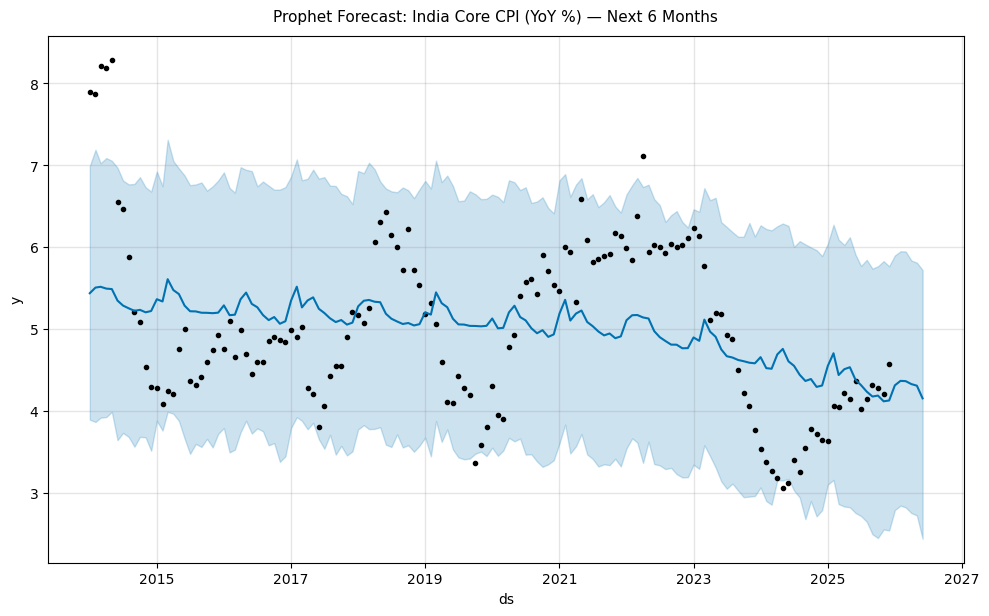

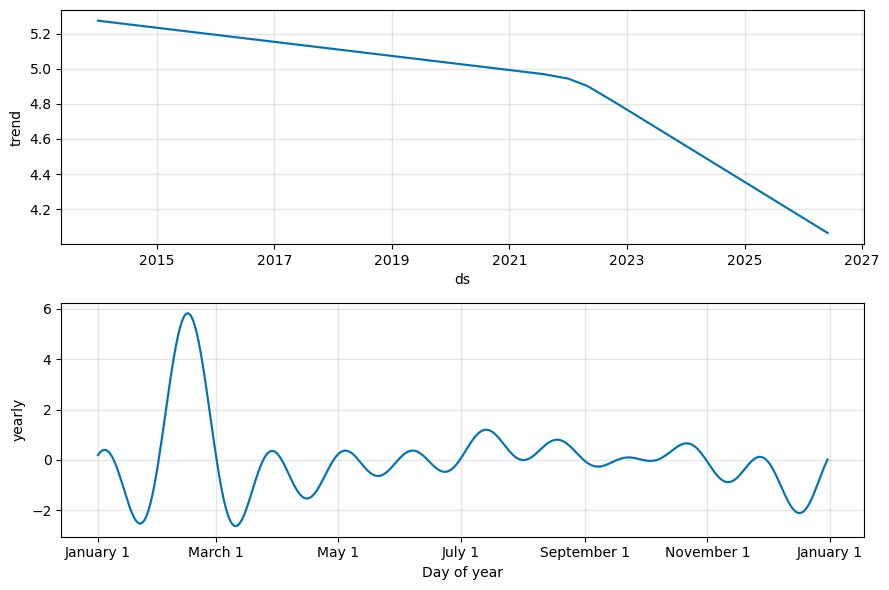

Forecasted values for the next 6 months (yhat = predicted, yhat_lower/upper = bounds):
        ds  yhat  yhat_lower  yhat_upper
2026-01-01  4.31        2.79        5.90
2026-02-01  4.37        2.85        5.95
2026-03-01  4.36        2.82        5.95
2026-04-01  4.33        2.75        5.84
2026-05-01  4.31        2.73        5.81
2026-06-01  4.15        2.44        5.72


In [10]:
# Prophet requires columns 'ds' (datestamp) and 'y' (target value)
core_prophet = df_cpi[['date', 'cpi_core_yoy']].rename(
    columns={'date': 'ds', 'cpi_core_yoy': 'y'}
).dropna()

# Initialize and fit Prophet model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive',  # CPI components represent additive YoY rates
    interval_width=0.90           # 90% uncertainty/confidence interval
)

model.fit(core_prophet)

# Generate future date dataframe for the next 6 months
future = model.make_future_dataframe(periods=6, freq='MS')
forecast = model.predict(future)

# Plot 1: 6-month forecast with confidence bands
fig1 = model.plot(forecast)
fig1.suptitle('Prophet Forecast: India Core CPI (YoY %) — Next 6 Months', fontsize=11, y=1.02)
plt.savefig('../outputs/04_prophet_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: Seasonal decomposition components
fig2 = model.plot_components(forecast)
plt.savefig('../outputs/05_prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the forecasted rates for the next 6 months
print("Forecasted values for the next 6 months (yhat = predicted, yhat_lower/upper = bounds):")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(6).round(2).to_string(index=False))

## 2. MPC Policy Action Classifier (XGBoost)
We build a binary classification model to predict whether the MPC will hike rates (`is_hike = 1`) or not (`is_hike = 0`).

### Feature Selection:
* Inflation levels: `cpi_general_yoy`, `cpi_food_yoy`, `cpi_fuel_yoy`, `cpi_core_yoy`
* Inflation trends: `core_lag1` (previous meeting), `core_lag2` (two meetings ago), `core_3m_avg`

### Cross-Validation Strategy:
* For time-series data, random split introduces lookahead bias. We use `TimeSeriesSplit` (5 splits) to validate the classifier sequentially over historical periods.

In [11]:
# Columns used as predictors
feature_cols = [
    'cpi_general_yoy', 'cpi_food_yoy', 'cpi_fuel_yoy', 'cpi_core_yoy',
    'core_lag1', 'core_lag2', 'core_3m_avg'
]

# Filter out rows with missing lags
model_df = df_mpc[feature_cols + ['is_hike']].dropna().copy()
X = model_df[feature_cols]
y = model_df['is_hike']

# Set up Time Series Cross-Validation
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []

print("=== Time-Series Cross-Validation Accuracy ===")
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    clf = xgb.XGBClassifier(
        n_estimators=50,
        max_depth=3,
        learning_rate=0.1,
        eval_metric='logloss',
        random_state=42
    )
    clf.fit(X_train, y_train)
    score = clf.score(X_test, y_test)
    cv_scores.append(score)
    print(f"Fold {fold + 1} Test Accuracy: {score:.3f}")

print(f"Average Time-Series CV Accuracy: {np.mean(cv_scores):.3f}")
print(f"(Note: Dataset has {len(model_df)} MPC meetings. Results should be interpreted as pattern identifiers rather than rigid forecasters.)")

=== Time-Series Cross-Validation Accuracy ===
Fold 1 Test Accuracy: 1.000
Fold 2 Test Accuracy: 1.000
Fold 3 Test Accuracy: 0.333
Fold 4 Test Accuracy: 1.000
Fold 5 Test Accuracy: 1.000
Average Time-Series CV Accuracy: 0.867
(Note: Dataset has 58 MPC meetings. Results should be interpreted as pattern identifiers rather than rigid forecasters.)


## 3. Explainable AI (SHAP Explainer)
We train a final model on the complete historical dataset and fit a SHAP tree explainer to check feature contributions. This tells us what macro indicators most strongly influence MPC hikes.

Initializing KernelExplainer...
Computing SHAP values...


  0%|          | 0/58 [00:00<?, ?it/s]

SHAP values computed successfully!


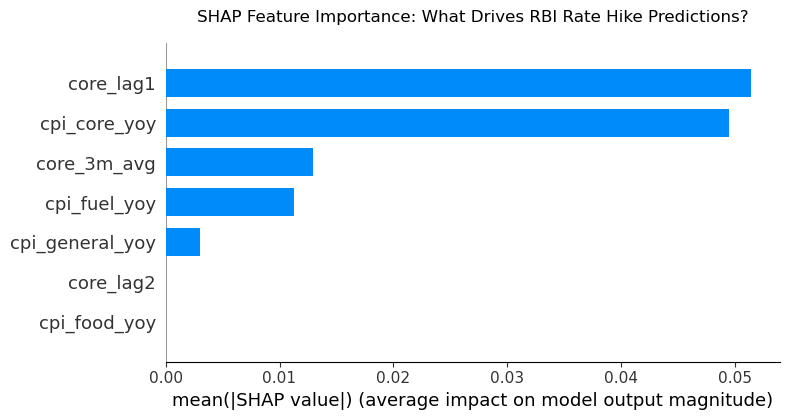

In [12]:
# Train final model
clf_final = xgb.XGBClassifier(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42
)
clf_final.fit(X, y)

# Fit KernelExplainer with a lambda wrapper to avoid XGBoost 3.0+ compatibility bugs
print("Initializing KernelExplainer...")
background = X.median().to_frame().T
explainer = shap.KernelExplainer(lambda x: clf_final.predict_proba(x), background)

print("Computing SHAP values...")
shap_values = explainer.shap_values(X)
print("SHAP values computed successfully!")

# Extract class-1 SHAP values (rate hikes)
# KernelExplainer returns a 3D array of shape (n_samples, n_features, 2)
pos_shap_values = shap_values[:, :, 1]
expected_val = explainer.expected_value[1]

# Plot 1: SHAP Feature Importance Bar Summary
plt.figure(figsize=(10, 6))
shap.summary_plot(
    pos_shap_values, 
    X, 
    feature_names=feature_cols,
    plot_type='bar',
    show=False
)
plt.title('SHAP Feature Importance: What Drives RBI Rate Hike Predictions?', fontsize=12, pad=15)
plt.tight_layout()
plt.savefig('../outputs/06_shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Single Decision Force Plot
We explain a specific decision (e.g. the first post-COVID hike on May 4, 2022) to trace which macro features pushed the probability toward a hike.

Explaining rate hike decision on date: 2022-05-04
Features at meeting:
cpi_general_yoy    7.04
cpi_food_yoy       7.84
cpi_fuel_yoy       9.54
cpi_core_yoy       5.94
core_lag1          7.11
core_lag2          5.84
core_3m_avg        6.29
Name: 34, dtype: float64


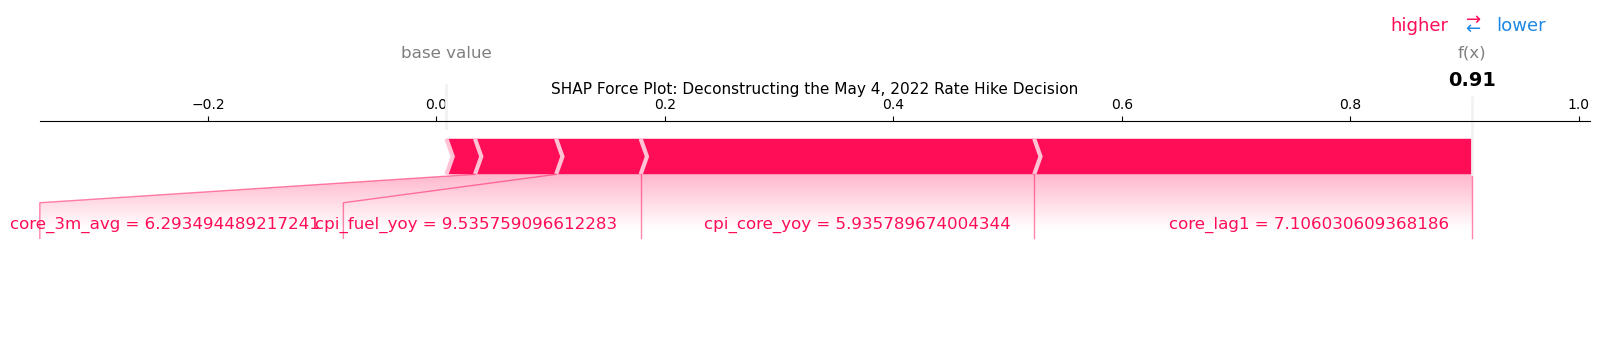

In [13]:
# Locate the row for the May 4, 2022 meeting
hike_idx = df_mpc[df_mpc['date'] == '2022-05-04'].index

if len(hike_idx) > 0:
    idx_val = hike_idx[0]
    # Find positional index inside the X matrix
    x_idx = model_df.index.get_loc(idx_val)
    
    print(f"Explaining rate hike decision on date: {df_mpc.loc[idx_val, 'date'].strftime('%Y-%m-%d')}")
    print("Features at meeting:")
    print(X.iloc[x_idx].round(2))
    
    # Render force plot for this decision
    shap.initjs() # initialize javascript visualization
    fig = shap.force_plot(
        expected_val, 
        pos_shap_values[x_idx], 
        X.iloc[x_idx], 
        matplotlib=True, 
        show=False
    )
    plt.title('SHAP Force Plot: Deconstructing the May 4, 2022 Rate Hike Decision', fontsize=11, pad=20)
    plt.savefig('../outputs/07_shap_single_decision.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Hike date 2022-05-04 not found in features index.")

In [4]:
pip install plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.9 MB 11.2 MB/s eta 0:00:01
   ----------- ---------------------------- 2.9/9.9 MB 9.3 MB/s eta 0:00:01
   ------------------ --------------------- 4.5/9.9 MB 8.4 MB/s eta 0:00:01
   ------------------------ --------------- 6.0/9.9 MB 8.2 MB/s eta 0:00:01
   ------------------------------ --------- 7.6/9.9 MB 8.1 MB/s eta 0:00:01
   ------------------------------------- -- 9.2/9.9 MB 7.9 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 7.5 MB/s  0:00:01

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/

In [5]:
import pandas as pd
from prophet import Prophet
import logging
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
logging.getLogger('prophet').setLevel(logging.WARNING)

# Load and prep data (same as your notebook)
df_cpi = pd.read_csv('../data/cleaned_cpi.csv')
df_cpi['date'] = pd.to_datetime(df_cpi['date'])
core_prophet = df_cpi[['date', 'cpi_core_yoy']].rename(
    columns={'date': 'ds', 'cpi_core_yoy': 'y'}
).dropna()

# Sanity-check the input range before fitting
print('n points:', len(core_prophet))
print('date range:', core_prophet.ds.min(), 'to', core_prophet.ds.max())
print('y range:', core_prophet.y.min(), 'to', core_prophet.y.max())

# Fit (identical config to your notebook)
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive',
    interval_width=0.90
)
model.fit(core_prophet)

future = model.make_future_dataframe(periods=6, freq='MS')
forecast = model.predict(future)

print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(6).round(2).to_string(index=False))

n points: 144
date range: 2014-01-01 00:00:00 to 2025-12-01 00:00:00
y range: 3.066106634113508 to 8.28184345902978
        ds  yhat  yhat_lower  yhat_upper
2026-01-01  4.31        2.71        5.97
2026-02-01  4.37        2.80        6.05
2026-03-01  4.36        2.72        5.96
2026-04-01  4.33        2.77        5.88
2026-05-01  4.31        2.65        5.92
2026-06-01  4.15        2.53        5.74


In [3]:
from prophet.diagnostics import cross_validation, performance_metrics

# Simulates repeatedly forecasting 6 months ahead from various past cutoffs,
# then compares against what actually happened
df_cv = cross_validation(
    model,
    initial='2555 days',   # ~7 years of initial training window
    period='180 days',     # re-forecast every ~6 months
    horizon='180 days'     # 6-month-ahead forecast, matching your use case
)
df_perf = performance_metrics(df_cv)
print(df_perf[['horizon', 'mape', 'coverage']].tail(6))

  0%|          | 0/9 [00:00<?, ?it/s]

06:52:28 - cmdstanpy - INFO - Chain [1] start processing
06:52:28 - cmdstanpy - INFO - Chain [1] done processing
06:52:29 - cmdstanpy - INFO - Chain [1] start processing
06:52:30 - cmdstanpy - INFO - Chain [1] done processing
06:52:30 - cmdstanpy - INFO - Chain [1] start processing
06:52:30 - cmdstanpy - INFO - Chain [1] done processing
06:52:30 - cmdstanpy - INFO - Chain [1] start processing
06:52:31 - cmdstanpy - INFO - Chain [1] done processing
06:52:31 - cmdstanpy - INFO - Chain [1] start processing
06:52:31 - cmdstanpy - INFO - Chain [1] done processing
06:52:31 - cmdstanpy - INFO - Chain [1] start processing
06:52:31 - cmdstanpy - INFO - Chain [1] done processing
06:52:32 - cmdstanpy - INFO - Chain [1] start processing
06:52:32 - cmdstanpy - INFO - Chain [1] done processing
06:52:32 - cmdstanpy - INFO - Chain [1] start processing
06:52:32 - cmdstanpy - INFO - Chain [1] done processing
06:52:33 - cmdstanpy - INFO - Chain [1] start processing
06:52:33 - cmdstanpy - INFO - Chain [1]

    horizon      mape  coverage
44 166 days  0.127724       1.0
45 169 days  0.221167       0.8
46 172 days  0.338091       0.6
47 175 days  0.382055       0.6
48 177 days  0.364472       0.6
49 180 days  0.361765       0.6


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

def evaluate_model(model_name):
    """Walk-forward evaluation reporting precision/recall/F1, not just accuracy —
    accuracy alone is misleading when only ~13% of meetings are hikes."""
    rows = []
    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        if model_name == 'logreg':
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)
            clf = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
        else:
            clf = xgb.XGBClassifier(n_estimators=50, max_depth=3, learning_rate=0.1,
                                     eval_metric='logloss', random_state=42)

        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)

        rows.append({
            'fold': fold + 1, 'n_test': len(y_test), 'actual_hikes': y_test.sum(),
            'pred_hikes': preds.sum(),
            'accuracy': accuracy_score(y_test, preds),
            'precision': precision_score(y_test, preds, zero_division=0),
            'recall': recall_score(y_test, preds, zero_division=0),
            'f1': f1_score(y_test, preds, zero_division=0)
        })
    return pd.DataFrame(rows)

print("=== XGBoost ===")
results_xgb = evaluate_model('xgb')
print(results_xgb.to_string(index=False))
print("Mean:", results_xgb[['accuracy','precision','recall','f1']].mean().round(3).to_dict())

print("\n=== Logistic Regression (class_weight='balanced') ===")
results_logreg = evaluate_model('logreg')
print(results_logreg.to_string(index=False))
print("Mean:", results_logreg[['accuracy','precision','recall','f1']].mean().round(3).to_dict())

=== XGBoost ===
 fold  n_test  actual_hikes  pred_hikes  accuracy  precision  recall  f1
    1       9             0           0  1.000000        0.0     0.0 0.0
    2       9             0           0  1.000000        0.0     0.0 0.0
    3       9             6           0  0.333333        0.0     0.0 0.0
    4       9             0           0  1.000000        0.0     0.0 0.0
    5       9             0           0  1.000000        0.0     0.0 0.0
Mean: {'accuracy': 0.867, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0}

=== Logistic Regression (class_weight='balanced') ===
 fold  n_test  actual_hikes  pred_hikes  accuracy  precision   recall       f1
    1       9             0           0  1.000000   0.000000 0.000000 0.000000
    2       9             0           7  0.222222   0.000000 0.000000 0.000000
    3       9             6           3  0.444444   0.666667 0.333333 0.444444
    4       9             0           0  1.000000   0.000000 0.000000 0.000000
    5       9             